In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats
from sklearn.metrics import r2_score

from Capricho.analysis import (
    DroppingComment,
    explode_assay_comparability,
    get_all_comments,
    plot_multi_panel_comparability,
    plot_subset,
)
from Capricho.core.pandas_helper import filter_dropping_flags

## Fetch Caco-2 permeability data

Caco-2 permeability data must be separated by transport direction:
- **A→B** (apical to basolateral): Measures absorption
- **B→A** (basolateral to apical): Measures efflux (often P-gp mediated)

The assay IDs below were identified using `capricho explore` with SQL queries filtering
for Caco-2 permeability assays by direction keywords in the assay description.
See [caco2_assay_discovery.sh](caco2_assay_discovery.sh) for the full discovery queries.

To fetch the data, we'll use the CLI with the following parameters:
```bash
capricho get --assay-ids CHEMBL3529272,CHEMBL3430218,...  \
    --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
    --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
    --convert-units --drop-unassigned-chiral \
    -o caco2_a_to_b.csv
```

In [3]:
from pathlib import Path

DATA_DIR = Path("data/caco2")
DATA_DIR.mkdir(exist_ok=True, parents=True)


A_TO_B_STR = ",".join(Path("ChEMBL-all-caco2-a2b-assays.txt").read_text().strip().split("\n"))
B_TO_A_STR = ",".join(Path("ChEMBL-all-caco2-b2a-assays.txt").read_text().strip().split("\n"))

ALL_ASSAYS = (A_TO_B_STR + "," + B_TO_A_STR).split(",")

ALL_CACO_ASSAYS_STR = ",".join(Path("ChEMBL-all-caco2-assays.txt").read_text().strip().split("\n"))

In [4]:
a_to_b_path = DATA_DIR / "caco2_a_to_b.csv"
if not a_to_b_path.exists():
    ! capricho get --assay-ids {A_TO_B_STR} \
        --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
        --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
        --convert-units --drop-unassigned-chiral \
        -o {str(a_to_b_path)}
else:
    print(f"Data already exists: {a_to_b_path}")
    print("Delete this file to re-fetch with the updated assay list.")

Data already exists: data/caco2/caco2_a_to_b.csv
Delete this file to re-fetch with the updated assay list.


In [5]:
b_to_a_path = DATA_DIR / "caco2_b_to_a.csv"
if not b_to_a_path.exists():
    ! capricho get --assay-ids {B_TO_A_STR} \
        --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
        --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
        --convert-units --drop-unassigned-chiral \
        -o {str(b_to_a_path)}
else:
    print(f"Data already exists: {b_to_a_path}")
    print("Delete this file to re-fetch with the updated assay list.")

Data already exists: data/caco2/caco2_b_to_a.csv
Delete this file to re-fetch with the updated assay list.


In addition to the correct directional fetching, we collect all ChEMBL data that mentions caco2 so that we can demonstrate the units that are included in the database.

In [6]:
all_caco2_path = DATA_DIR / "caco2-all-chembl_data.csv"

if not all_caco2_path.exists():
    ! capricho get --assay-ids {ALL_CACO_ASSAYS_STR} \
        --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
        --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
        --convert-units --drop-unassigned-chiral \
        -o {str(all_caco2_path)}
else:
    print(f"Data already exists: {all_caco2_path}")
    print("Delete this file to re-fetch with the updated assay list.")

Data already exists: data/caco2/caco2-all-chembl_data.csv
Delete this file to re-fetch with the updated assay list.


## Data overview

In [7]:
df_a2b = pd.read_csv(a_to_b_path, engine="pyarrow")
df_b2a = pd.read_csv(b_to_a_path, engine="pyarrow")

df_not_agg = pd.concat(
    [
        pd.read_csv(DATA_DIR / "caco2-all-chembl_data_not_aggregated.csv", engine="pyarrow"),
        # pd.read_csv(DATA_DIR / "caco2_b_to_a_not_aggregated.csv", engine="pyarrow"),
    ]
)

print(
    f"A→B:  {len(df_a2b):>5} compounds, {df_a2b['assay_chembl_id'].astype(str).str.split('|').explode().nunique()} assays"
)
print(
    f"B→A:  {len(df_b2a):>5} compounds, {df_b2a['assay_chembl_id'].astype(str).str.split('|').explode().nunique()} assays"
)
print(
    f"Not-aggregated (all): {len(df_not_agg)} measurements, {df_not_agg['molecule_chembl_id'].nunique()} compounds"
)

A→B:   1870 compounds, 90 assays
B→A:    777 compounds, 49 assays
Not-aggregated (all): 6477 measurements, 3788 compounds


## Data type heterogeneity in ChEMBL

Caco-2 permeability data in ChEMBL is reported under several different `standard_type` labels.
This heterogeneity complicates automated data extraction.

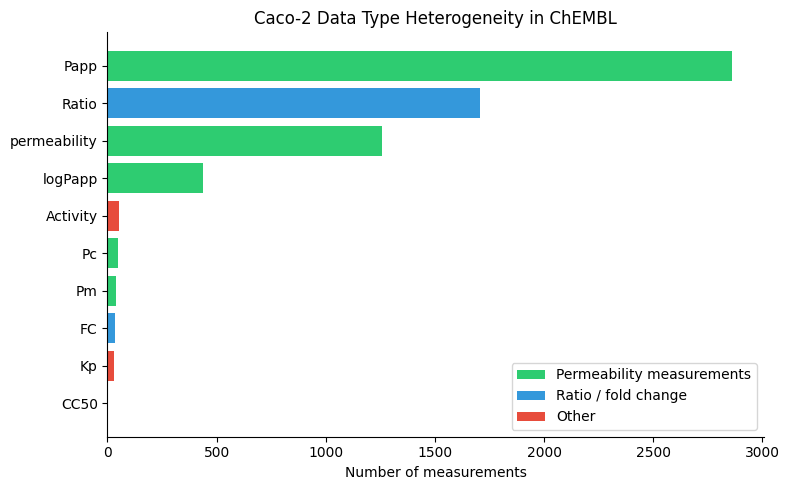

In [8]:
type_counts = df_not_agg["standard_type"].value_counts()

# Color by whether the type is a direct permeability measurement
PERMEABILITY_TYPES = {"Papp", "permeability", "logPapp", "Pc", "Pm"}
RATIO_TYPES = {"Ratio", "FC"}

colors = []
for t in type_counts.index:
    if t in PERMEABILITY_TYPES:
        colors.append("#2ecc71")  # green - direct permeability
    elif t in RATIO_TYPES:
        colors.append("#3498db")  # blue - ratio / fold change
    else:
        colors.append("#e74c3c")  # red - other

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(type_counts)), type_counts.values, color=colors)
ax.set_yticks(range(len(type_counts)))
ax.set_yticklabels(type_counts.index)
ax.set_xlabel("Number of measurements")
ax.set_title("Caco-2 Data Type Heterogeneity in ChEMBL")
ax.invert_yaxis()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="#2ecc71", label="Permeability measurements"),
    Patch(facecolor="#3498db", label="Ratio / fold change"),
    Patch(facecolor="#e74c3c", label="Other"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.tight_layout()
plt.show()

## Unit heterogeneity

Even within the same property (permeability), ChEMBL data uses many different unit representations.
CAPRICHO's `--convert-units` flag standardises these to `10^-6 cm/s`.

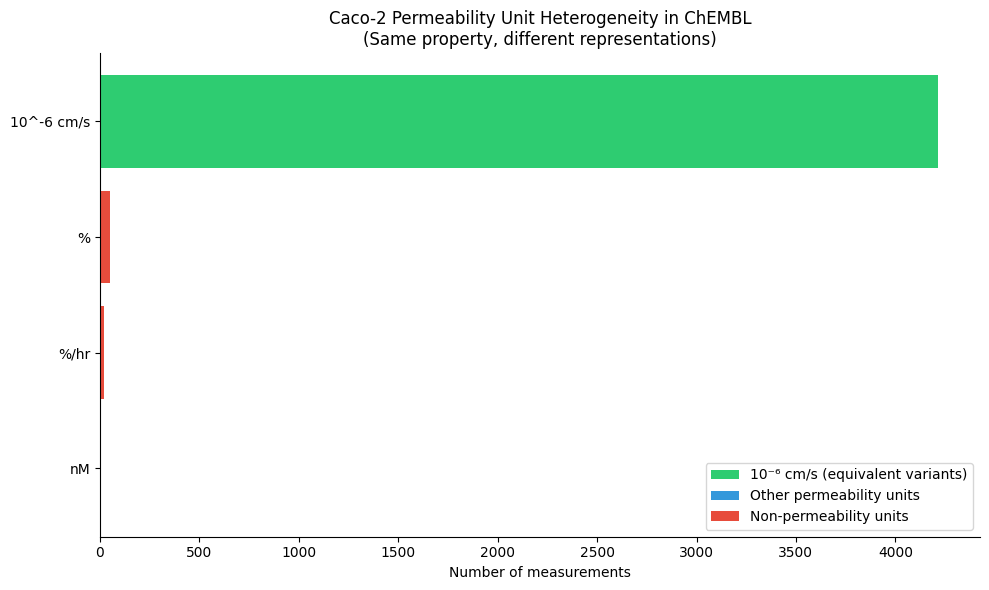


Unit types: 4
10⁻⁶ cm/s variants: 4215 (65.1%)


In [9]:
UNIT_MAPPING = {
    "10'-6 cm/s": "10\u207b\u2076 cm/s variants",
    "10^-6 cm/s": "10\u207b\u2076 cm/s variants",
    "ucm/s": "10\u207b\u2076 cm/s variants",
    "10'6cm/s": "10\u207b\u2076 cm/s variants",
    "10^6cm/s": "10\u207b\u2076 cm/s variants",
    "1E-6 cm/s": "10\u207b\u2076 cm/s variants",
    "1e-6 cm/s": "10\u207b\u2076 cm/s variants",
    "10-6 cm/s": "10\u207b\u2076 cm/s variants",
    "nm/s": "nm/s",
    "cm/s": "cm/s",
    "cm s-1": "cm/s",
    "cm/s * 10E6": "cm/s (scaled)",
    "10'-7 cm/s": "10\u207b\u2077 cm/s",
    "10'-6nanometer/s": "10\u207b\u2076 nm/s",
    "nm s-1": "nm/s",
    "10^-5 cm/min": "10\u207b\u2075 cm/min",
    "10'-5cm/s": "10\u207b\u2075 cm/s",
    "10'-5 cm/s": "10\u207b\u2075 cm/s",
    "10^-5 cm/s": "10\u207b\u2075 cm/s",
    "10^-5cm/s": "10\u207b\u2075 cm/s",
    "10'-8m/s": "10\u207b\u2078 m/s",
    "10'-9meter/s": "10\u207b\u2079 m/s",
    "%": "% (non-permeability)",
    "%/hr": "%/hr (rate)",
    "nM/s": "nM/s (rate)",
    "nM": "nM (concentration)",
}

CONVERTIBLE_PERMEABILITY = {
    "nm/s",
    "cm/s",
    "cm/s (scaled)",
    "10\u207b\u2077 cm/s",
    "10\u207b\u2075 cm/min",
    "10\u207b\u2076 nm/s",
    "10\u207b\u2075 cm/s",
    "10\u207b\u2078 m/s",
    "10\u207b\u2079 m/s",
}

unit_counts = df_not_agg["standard_units"].value_counts()

colors = []
for unit in unit_counts.index:
    cat = UNIT_MAPPING.get(unit, "Other")
    if cat == "10\u207b\u2076 cm/s variants":
        colors.append("#2ecc71")  # green - equivalent variants
    elif cat in CONVERTIBLE_PERMEABILITY:
        colors.append("#3498db")  # blue - convertible permeability
    else:
        colors.append("#e74c3c")  # red - non-standard

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(unit_counts)), unit_counts.values, color=colors)
ax.set_yticks(range(len(unit_counts)))
ax.set_yticklabels(unit_counts.index)
ax.set_xlabel("Number of measurements")
ax.set_title(
    "Caco-2 Permeability Unit Heterogeneity in ChEMBL\n" "(Same property, different representations)"
)
ax.invert_yaxis()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="#2ecc71", label="10\u207b\u2076 cm/s (equivalent variants)"),
    Patch(facecolor="#3498db", label="Other permeability units"),
    Patch(facecolor="#e74c3c", label="Non-permeability units"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.tight_layout()
plt.show()

# Print summary
equiv_variants = [
    "10'-6 cm/s",
    "10^-6 cm/s",
    "ucm/s",
    "10'6cm/s",
    "10^6cm/s",
    "1E-6 cm/s",
    "1e-6 cm/s",
    "10-6 cm/s",
]
n_equiv = df_not_agg[df_not_agg["standard_units"].isin(equiv_variants)].shape[0]
print(f"\nUnit types: {df_not_agg['standard_units'].nunique()}")
print(f"10\u207b\u2076 cm/s variants: {n_equiv} ({100 * n_equiv / len(df_not_agg):.1f}%)")

## Cross-assay comparability (A→B direction)

After unit conversion, we can assess cross-assay comparability for the A→B (absorption)
direction. Compounds measured across multiple assays allow pairwise comparison.

In [10]:
subset_a2b = df_a2b.query('assay_chembl_id.str.contains("|", regex=False)').assign(
    repeat=lambda x: range(len(x))
)
print(f"A→B compounds with multi-assay measurements: {len(subset_a2b)}")

exploded_a2b = explode_assay_comparability(
    subset_a2b,
    sep_str="|",
    value_column="standard_value",
)
print(f"Pairwise comparisons: {len(exploded_a2b)}")

A→B compounds with multi-assay measurements: 147
Pairwise comparisons: 188


INFO     | COMPARABILITY: Undefined Stereochemistry — 121 pairwise comparisons
  Within ±0.3 log units:       67 ( 55.4%)
  Within ±1.0 log units:      120 ( 99.2%)
  Outside ±1.0 log units:       1 (  0.8%)
  Spearman rho: 0.540  |  R²: 0.278
INFO     | COMPARABILITY: Unit converted to — 67 pairwise comparisons
  Within ±0.3 log units:       45 ( 67.2%)
  Within ±1.0 log units:       65 ( 97.0%)
  Outside ±1.0 log units:       2 (  3.0%)
  Spearman rho: 0.851  |  R²: 0.613


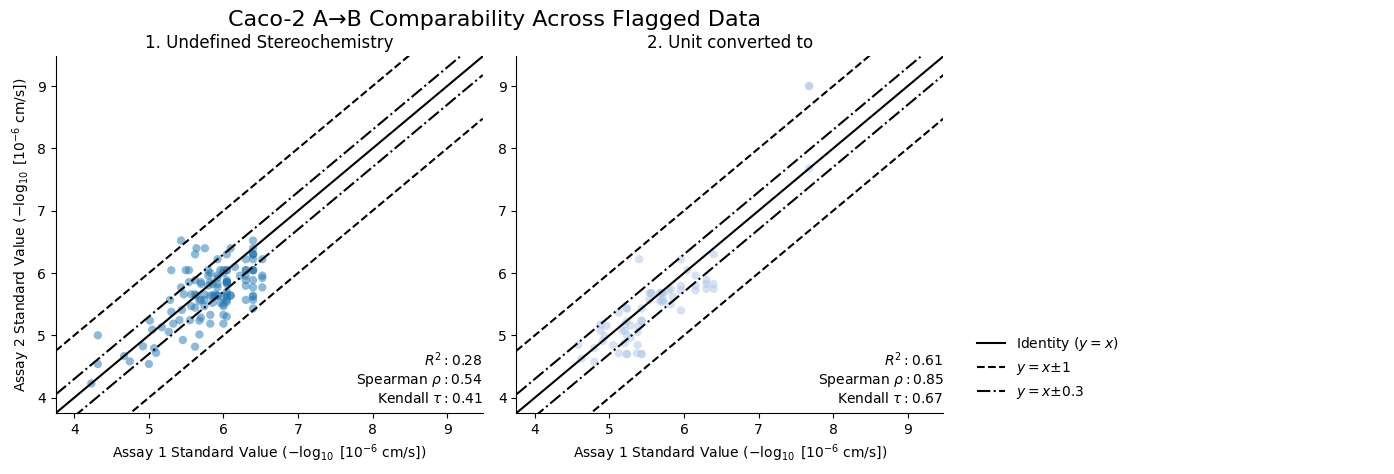

In [11]:
all_comments = get_all_comments()

fig, axs = plot_multi_panel_comparability(
    exploded_a2b,
    all_comments,
    title="Caco-2 A\u2192B Comparability Across Flagged Data",
    figsize=(10, 4.6),
    ncols=2,
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=0.5,
)

fig.savefig("caco2_a2b_flagged_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

## Unprocessed data

INFO     | COMPARABILITY: Unprocessed Caco-2 A→B Data — 172 pairwise comparisons
  Within ±0.3 log units:       96 ( 55.8%)
  Within ±1.0 log units:      169 ( 98.3%)
  Outside ±1.0 log units:       3 (  1.7%)
  Spearman rho: 0.689  |  Kendall tau: 0.514  |  R²: 0.331


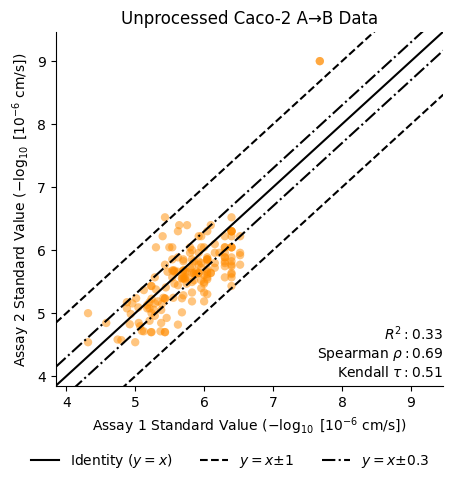

In [18]:
unprocessed = filter_dropping_flags(
    exploded_a2b.query("standard_value_x != standard_value_y"),
    [DroppingComment.DATA_VALIDITY_COMMENT],
    column="dropping_comment",
)

fig, ax = plot_subset(
    unprocessed,
    title="Unprocessed Caco-2 A\u2192B Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=0.5,
    color="darkorange",
)
fig.savefig("caco2_a2b_unprocessed.png", dpi=300, bbox_inches="tight", transparent=False)

## Cleaned data

INFO     | Filtering 112 rows with flag: 'Undefined Stereochemistry'
INFO     | Total rows filtered out: 112/172 (65.1%)
INFO     | COMPARABILITY: Cleaned Caco-2 A→B Data — 60 pairwise comparisons
  Within ±0.3 log units:       38 ( 63.3%)
  Within ±1.0 log units:       58 ( 96.7%)
  Outside ±1.0 log units:       2 (  3.3%)
  Spearman rho: 0.826  |  Kendall tau: 0.638  |  R²: 0.485


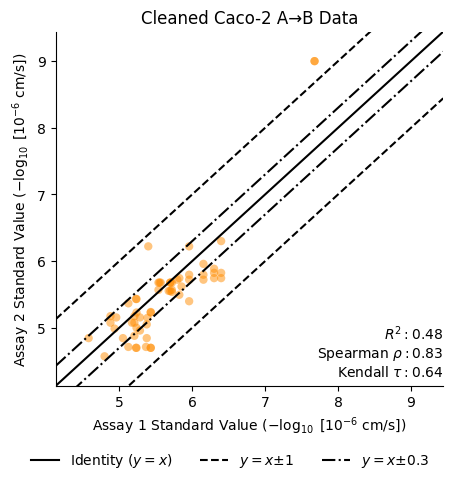

In [19]:
cleaned = filter_dropping_flags(
    exploded_a2b.query("standard_value_x != standard_value_y"),
    [
        DroppingComment.DATA_VALIDITY_COMMENT,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY,
    ],
    column="dropping_comment",
)


fig, ax = plot_subset(
    cleaned,
    title="Cleaned Caco-2 A\u2192B Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=0.5,
    color="darkorange",
)
fig.savefig("caco2_a2b_cleaned.png", dpi=300, bbox_inches="tight", transparent=False)

## Cross-assay comparability (B→A direction)

The same analysis for the B→A (efflux) direction.

In [20]:
subset_b2a = df_b2a.query('assay_chembl_id.str.contains("|", regex=False)').assign(
    repeat=lambda x: range(len(x))
)
print(f"B→A compounds with multi-assay measurements: {len(subset_b2a)}")

exploded_b2a = explode_assay_comparability(
    subset_b2a,
    sep_str="|",
    value_column="standard_value",
)
print(f"Pairwise comparisons: {len(exploded_b2a)}")

B→A compounds with multi-assay measurements: 90
Pairwise comparisons: 179


INFO     | COMPARABILITY: Undefined Stereochemistry — 118 pairwise comparisons
  Within ±0.3 log units:       83 ( 70.3%)
  Within ±1.0 log units:      117 ( 99.2%)
  Outside ±1.0 log units:       1 (  0.8%)
  Spearman rho: 0.641  |  Kendall tau: 0.460  |  R²: 0.321
INFO     | COMPARABILITY: Unit converted to — 61 pairwise comparisons
  Within ±0.3 log units:       51 ( 83.6%)
  Within ±1.0 log units:       61 (100.0%)
  Outside ±1.0 log units:       0 (  0.0%)
  Spearman rho: 0.771  |  Kendall tau: 0.594  |  R²: 0.847


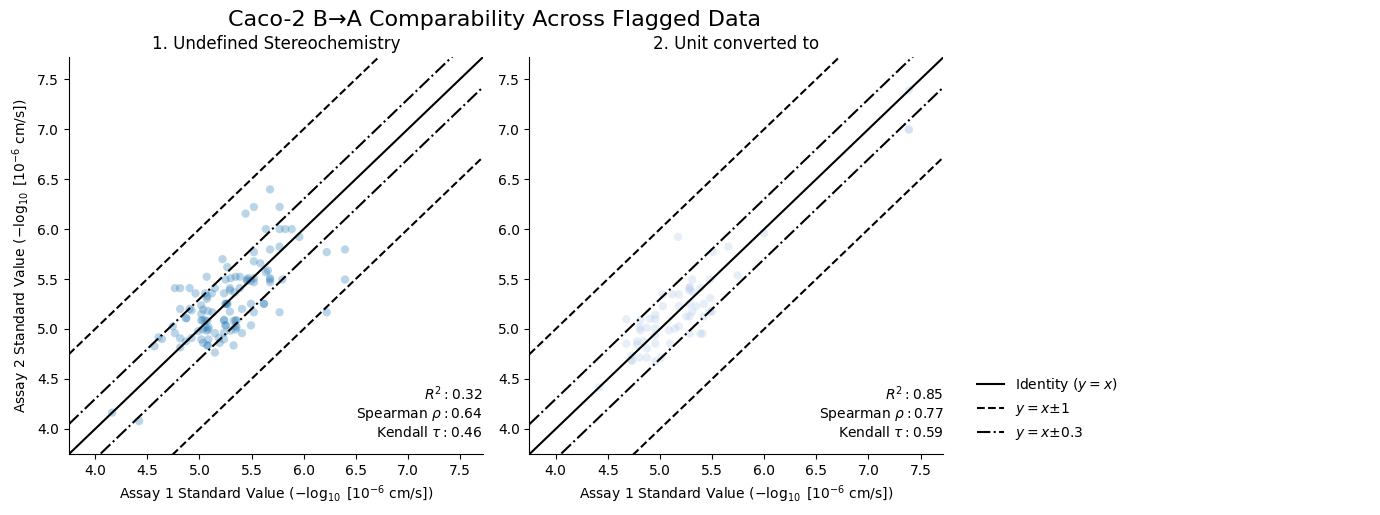

In [21]:
fig, axs = plot_multi_panel_comparability(
    exploded_b2a,
    all_comments,
    title="Caco-2 B\u2192A Comparability Across Flagged Data",
    figsize=(10, 5),
    ncols=2,
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
)
fig.savefig("caco2_b2a_flagged_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

INFO     | COMPARABILITY: Unprocessed Caco-2 B→A Data — 173 pairwise comparisons
  Within ±0.3 log units:      128 ( 74.0%)
  Within ±1.0 log units:      172 ( 99.4%)
  Outside ±1.0 log units:       1 (  0.6%)
  Spearman rho: 0.677  |  Kendall tau: 0.496  |  R²: 0.524


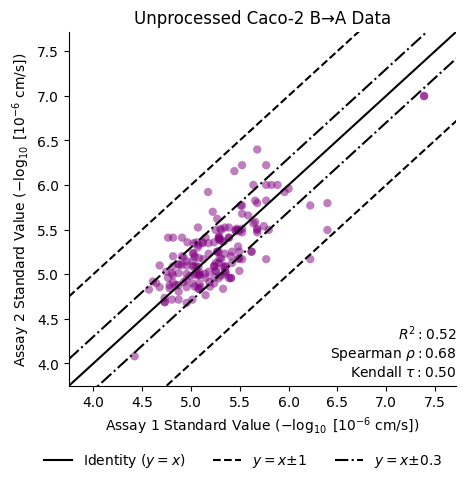

In [22]:
unprocessed_b2a = filter_dropping_flags(
    exploded_b2a.query("standard_value_x != standard_value_y"),
    [DroppingComment.DATA_VALIDITY_COMMENT],
    column="dropping_comment",
)

fig, ax = plot_subset(
    unprocessed_b2a,
    title="Unprocessed Caco-2 B\u2192A Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=0.5,
    color="purple",
)
fig.savefig("caco2_b2a_unprocessed.png", dpi=300, bbox_inches="tight", transparent=False)

INFO     | Filtering 114 rows with flag: 'Undefined Stereochemistry'
INFO     | Total rows filtered out: 114/173 (65.9%)


INFO     | COMPARABILITY: Cleaned Caco-2 B→A Data — 59 pairwise comparisons
  Within ±0.3 log units:       49 ( 83.1%)
  Within ±1.0 log units:       59 (100.0%)
  Outside ±1.0 log units:       0 (  0.0%)
  Spearman rho: 0.747  |  Kendall tau: 0.566  |  R²: 0.792


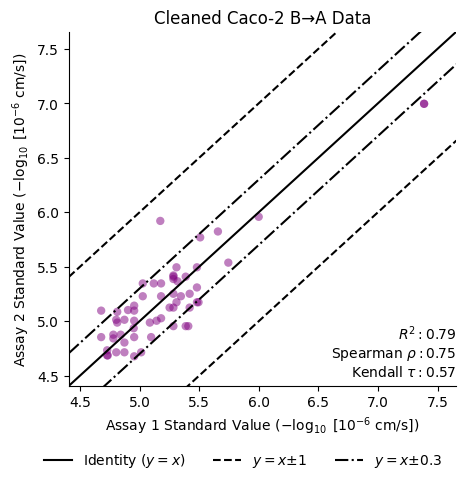

In [23]:
cleaned_b2a_exploded = filter_dropping_flags(
    exploded_b2a.query("standard_value_x != standard_value_y"),
    [
        DroppingComment.DATA_VALIDITY_COMMENT,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY,
    ],
    column="dropping_comment",
)

fig, ax = plot_subset(
    cleaned_b2a_exploded,
    title="Cleaned Caco-2 B\u2192A Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=0.5,
    color="purple",
)
fig.savefig("caco2_b2a_cleaned.png", dpi=300, bbox_inches="tight", transparent=False)

## Mixed-direction comparability (A→B + B→A combined)

When A→B and B→A measurements are naively combined without direction separation,
cross-assay comparability degrades severely because absorption and efflux represent
fundamentally different transport mechanisms.

In [26]:
mixed_path = DATA_DIR / "caco2_mixed_directions.csv"
MIXED_STR = A_TO_B_STR + "," + B_TO_A_STR

if not mixed_path.exists():
    ! capricho get --assay-ids {MIXED_STR} \
        --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
        --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
        --convert-units --drop-unassigned-chiral \
        -o {str(mixed_path)}
else:
    print(f"Data already exists: {mixed_path}")

INFO     | Log level set to INFO
INFO     | No valid pairs with non-NaN activity values found for curation.
INFO     | Converting units to standard formats
INFO     | Converting 2999 permeability measurements to standard unit (10^-6 cm/s). 54 measurements cannot be converted (unknown units or missing values).
INFO     | Flagging 2999 activities with converted units.
INFO     | No molar concentration measurements found that can be converted to standard unit.
INFO     | No mass concentration measurements found that can be converted to standard unit.
INFO     | No dose measurements found that can be converted to standard unit.
INFO     | No time measurements found that can be converted to standard unit.
Find undefined stereocenters: 100%|██████████| 16/16 [00:00<00:00, 21.21chunk/s]
INFO     | Flagging 1897 rows with undefined stereocenters.
Converting to connectivity: 100%|████████████| 16/16 [00:01<00:00, 12.17chunk/s]
INFO     | Found 487 repeats with more than 1 log unit difference.
I

In [27]:
df_mixed = pd.read_csv(mixed_path, engine="pyarrow")
subset_mixed = df_mixed.query('assay_chembl_id.str.contains("|", regex=False)').assign(
    repeat=lambda x: range(len(x))
)
print(f"Mixed-direction compounds with multi-assay measurements: {len(subset_mixed)}")

exploded_mixed = explode_assay_comparability(
    subset_mixed,
    sep_str="|",
    value_column="standard_value",
)
print(f"Pairwise comparisons: {len(exploded_mixed)}")

Mixed-direction compounds with multi-assay measurements: 544
Pairwise comparisons: 1383


In [ ]:
mixed_unprocessed = filter_dropping_flags(
    exploded_mixed.query("standard_value_x != standard_value_y"),
    [DroppingComment.DATA_VALIDITY_COMMENT],
    column="dropping_comment",
)

fig, ax = plot_subset(
    mixed_unprocessed,
    title="Mixed-Direction Caco-2 Data (A→B + B→A)",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=0.5,
    color="crimson",
)
fig.savefig("caco2_mixed_directions.png", dpi=300, bbox_inches="tight", transparent=False)

## Prepare data for modeling

The `capricho prepare` command filters quality flags and pivots the data into an activity
matrix (compounds × tasks) ready for ML. Note that for Caco-2, A→B and B→A should be
treated as separate tasks.

**Option 1** — CLI:
```bash
capricho prepare -i caco2_a_to_b.csv -o caco2_a2b_prepared.csv \
    --drop-unit-error --drop-undefined-stereo --drop-assay-size
```

**Option 2** — Python API (used below).

In [29]:
from Capricho.cli.prepare import clean_data

cleaned_a2b = clean_data(
    df_a2b,
    deduplicate=True,
    drop_flags=[
        DroppingComment.UNIT_ANNOTATION_ERROR.value,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY.value,
        DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
    ],
    value_col="standard_value",
)

cleaned_b2a = clean_data(
    df_b2a,
    deduplicate=True,
    drop_flags=[
        DroppingComment.UNIT_ANNOTATION_ERROR.value,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY.value,
        DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
    ],
    value_col="standard_value",
)

print(f"A\u2192B: {df_a2b.shape[0]} before cleaning & {len(cleaned_a2b)} after cleaning")
print(f"B\u2192A: {df_b2a.shape[0]} before cleaning & {len(cleaned_b2a)} after cleaning")

INFO     | Deduplicating identical values within aggregated rows...
INFO     | Deduplication removed 21 duplicate values
INFO     | Recalculating statistics after deduplication...
INFO     | Rows with flag 'Undefined Stereochemistry': 1084
INFO     | Rows fully removed (all measurements flagged): 1084
INFO     | Total rows affected: 1084/1870 (58.0%)
INFO     | 
PREPARATION SUMMARY
  Input rows:                   1,870
  After deduplication:          1,870  (removed 21 duplicate values)
  After flag filtering:           786  (removed 1084 rows)
  Final rows:                     786
INFO     | Deduplicating identical values within aggregated rows...
INFO     | Deduplication removed 6 duplicate values
INFO     | Recalculating statistics after deduplication...
INFO     | Rows with flag 'Undefined Stereochemistry': 492
INFO     | Rows fully removed (all measurements flagged): 492
INFO     | Total rows affected: 492/777 (63.3%)
INFO     | 
PREPARATION SUMMARY
  Input rows:                  

A→B: 1870 before cleaning & 786 after cleaning
B→A: 777 before cleaning & 285 after cleaning


## MDCK-MDR1 Permeability Case Study

MDCK-MDR1 cells (Madin-Darby Canine Kidney cells transfected with human P-glycoprotein/MDR1)
are another widely used model for permeability studies. Like Caco-2 cells, they form polarized
monolayers with apical and basolateral sides, so transport directions map directly:

- **MDCK-MDR1 A→B** = absorption direction (same concept as Caco-2 A→B)
- **MDCK-MDR1 B→A** = efflux direction (same concept as Caco-2 B→A)

However, absolute values are **not directly comparable** across cell lines due to different
transporter expression levels (MDCK-MDR1 overexpresses P-gp, while Caco-2 expresses it
endogenously at lower levels).

**P-gp inhibitor assays:** Some MDCK-MDR1 assays are performed in the presence of P-gp
inhibitors (e.g., elacridar, verapamil, cyclosporin A). Since P-gp mediates efflux (B→A),
these inhibitor assays are excluded from the **B→A** list but **included** in the **A→B**
list — P-gp inhibition does not affect passive absorption-direction permeability.

See [caco2_assay_discovery.sh](caco2_assay_discovery.sh) for the MDCK-MDR1 assay discovery queries.

In [19]:
MDCK_DATA_DIR = Path("data/mdck_mdr1")
MDCK_DATA_DIR.mkdir(exist_ok=True, parents=True)

MDCK_A_TO_B_STR = ",".join(Path("ChEMBL-all-mdck-mdr1-a2b-assays.txt").read_text().strip().split("\n"))
MDCK_B_TO_A_STR = ",".join(Path("ChEMBL-all-mdck-mdr1-b2a-assays.txt").read_text().strip().split("\n"))
MDCK_ALL_STR = ",".join(Path("ChEMBL-all-mdck-mdr1-assays.txt").read_text().strip().split("\n"))

print(f"MDCK-MDR1 A→B assays: {len(MDCK_A_TO_B_STR.split(','))}")
print(f"MDCK-MDR1 B→A assays: {len(MDCK_B_TO_A_STR.split(','))}")
print(f"MDCK-MDR1 all assays: {len(MDCK_ALL_STR.split(','))}")

MDCK-MDR1 A→B assays: 131
MDCK-MDR1 B→A assays: 42
MDCK-MDR1 all assays: 221


In [20]:
mdck_a2b_path = MDCK_DATA_DIR / "mdck_mdr1_a_to_b.csv"
if not mdck_a2b_path.exists():
    ! capricho get --assay-ids {MDCK_A_TO_B_STR} \
        --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
        --bioactivity-type Papp,permeability,logPapp,Pc,Pm \
        --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
        --convert-units --drop-unassigned-chiral \
        -o {str(mdck_a2b_path)}
else:
    print(f"Data already exists: {mdck_a2b_path}")
    print("Delete this file to re-fetch with the updated assay list.")

Data already exists: data/mdck_mdr1/mdck_mdr1_a_to_b.csv
Delete this file to re-fetch with the updated assay list.


In [21]:
mdck_b2a_path = MDCK_DATA_DIR / "mdck_mdr1_b_to_a.csv"
if not mdck_b2a_path.exists():
    ! capricho get --assay-ids {MDCK_B_TO_A_STR} \
        --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
        --bioactivity-type Papp,permeability,logPapp,Pc,Pm \
        --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
        --convert-units --drop-unassigned-chiral \
        -o {str(mdck_b2a_path)}
else:
    print(f"Data already exists: {mdck_b2a_path}")
    print("Delete this file to re-fetch with the updated assay list.")

Data already exists: data/mdck_mdr1/mdck_mdr1_b_to_a.csv
Delete this file to re-fetch with the updated assay list.


We also collect all MDCK-MDR1 permeability data (regardless of direction) for the
type and unit heterogeneity analysis.

In [22]:
all_mdck_path = MDCK_DATA_DIR / "mdck_mdr1_all_chembl_data.csv"
if not all_mdck_path.exists():
    ! capricho get --assay-ids {MDCK_ALL_STR} \
        --assay-types A --confidence-scores 0,1,2,3,4,5,6,7,8,9 \
        --bioactivity-type Papp,permeability,logPapp,Pc,Pm \
        --aggregate-on standard_value --id-columns standard_units,assay_cell_type \
        --convert-units --drop-unassigned-chiral \
        -o {str(all_mdck_path)}
else:
    print(f"Data already exists: {all_mdck_path}")
    print("Delete this file to re-fetch with the updated assay list.")

Data already exists: data/mdck_mdr1/mdck_mdr1_all_chembl_data.csv
Delete this file to re-fetch with the updated assay list.


### MDCK-MDR1 Data overview

In [23]:
mdck_a2b = pd.read_csv(mdck_a2b_path, engine="pyarrow")
mdck_b2a = pd.read_csv(mdck_b2a_path, engine="pyarrow")

mdck_not_agg = pd.read_csv(MDCK_DATA_DIR / "mdck_mdr1_all_chembl_data_not_aggregated.csv", engine="pyarrow")

print(
    f"A→B:  {len(mdck_a2b):>5} compounds, "
    f"{mdck_a2b['assay_chembl_id'].astype(str).str.split('|').explode().nunique()} assays"
)
print(
    f"B→A:  {len(mdck_b2a):>5} compounds, "
    f"{mdck_b2a['assay_chembl_id'].astype(str).str.split('|').explode().nunique()} assays"
)
print(
    f"Not-aggregated (all): {len(mdck_not_agg)} measurements, "
    f"{mdck_not_agg['molecule_chembl_id'].nunique()} compounds"
)

A→B:   1397 compounds, 126 assays
B→A:    402 compounds, 41 assays
Not-aggregated (all): 2504 measurements, 1939 compounds


### MDCK-MDR1 Data type heterogeneity

Similar to Caco-2, MDCK-MDR1 permeability data in ChEMBL is reported under several
different `standard_type` labels.

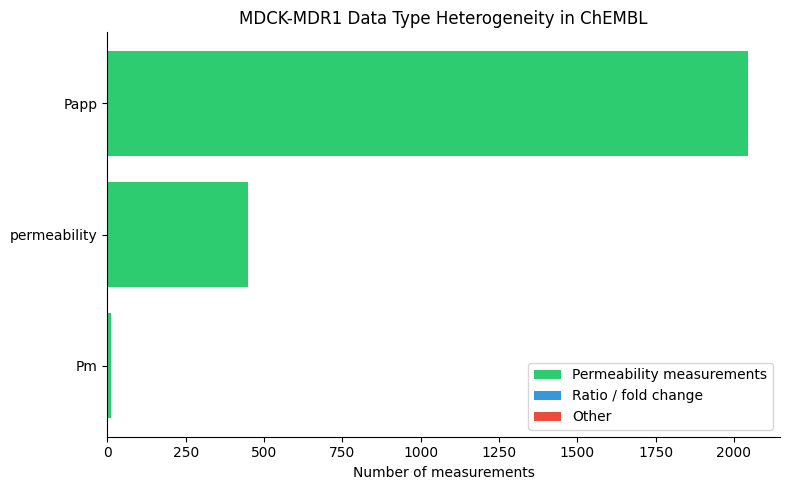

In [24]:
mdck_type_counts = mdck_not_agg["standard_type"].value_counts()

colors = []
for t in mdck_type_counts.index:
    if t in PERMEABILITY_TYPES:
        colors.append("#2ecc71")
    elif t in RATIO_TYPES:
        colors.append("#3498db")
    else:
        colors.append("#e74c3c")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(mdck_type_counts)), mdck_type_counts.values, color=colors)
ax.set_yticks(range(len(mdck_type_counts)))
ax.set_yticklabels(mdck_type_counts.index)
ax.set_xlabel("Number of measurements")
ax.set_title("MDCK-MDR1 Data Type Heterogeneity in ChEMBL")
ax.invert_yaxis()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="#2ecc71", label="Permeability measurements"),
    Patch(facecolor="#3498db", label="Ratio / fold change"),
    Patch(facecolor="#e74c3c", label="Other"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.tight_layout()
plt.show()

### MDCK-MDR1 Unit heterogeneity

The same chaotic mix of unit representations seen in Caco-2 data also appears in MDCK-MDR1.
CAPRICHO's `--convert-units` flag handles these automatically.

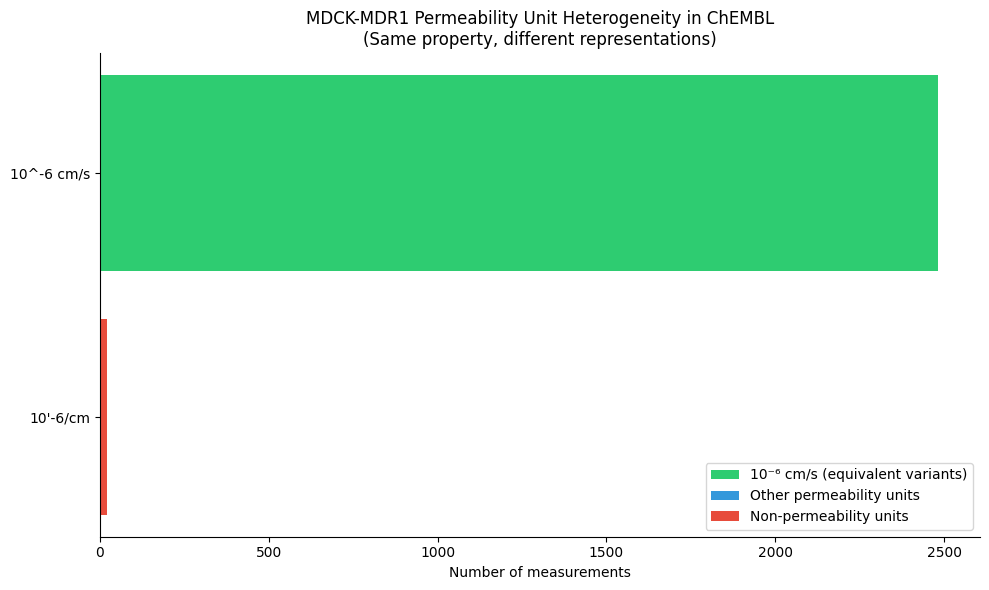


Unit types: 2
10⁻⁶ cm/s variants: 2482 (99.1%)


In [25]:
mdck_unit_counts = mdck_not_agg["standard_units"].value_counts()

colors = []
for unit in mdck_unit_counts.index:
    cat = UNIT_MAPPING.get(unit, "Other")
    if cat == "10\u207b\u2076 cm/s variants":
        colors.append("#2ecc71")
    elif cat in CONVERTIBLE_PERMEABILITY:
        colors.append("#3498db")
    else:
        colors.append("#e74c3c")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(mdck_unit_counts)), mdck_unit_counts.values, color=colors)
ax.set_yticks(range(len(mdck_unit_counts)))
ax.set_yticklabels(mdck_unit_counts.index)
ax.set_xlabel("Number of measurements")
ax.set_title(
    "MDCK-MDR1 Permeability Unit Heterogeneity in ChEMBL\n" "(Same property, different representations)"
)
ax.invert_yaxis()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="#2ecc71", label="10\u207b\u2076 cm/s (equivalent variants)"),
    Patch(facecolor="#3498db", label="Other permeability units"),
    Patch(facecolor="#e74c3c", label="Non-permeability units"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.tight_layout()
plt.show()

mdck_equiv = mdck_not_agg[mdck_not_agg["standard_units"].isin(equiv_variants)].shape[0]
print(f"\nUnit types: {mdck_not_agg['standard_units'].nunique()}")
print(f"10\u207b\u2076 cm/s variants: {mdck_equiv} ({100 * mdck_equiv / len(mdck_not_agg):.1f}%)")

### MDCK-MDR1 Cross-assay comparability (A→B direction)

In [26]:
mdck_subset_a2b = mdck_a2b.query('assay_chembl_id.str.contains("|", regex=False)').assign(
    repeat=lambda x: range(len(x))
)
print(f"MDCK-MDR1 A→B compounds with multi-assay measurements: {len(mdck_subset_a2b)}")

mdck_exploded_a2b = explode_assay_comparability(
    mdck_subset_a2b,
    sep_str="|",
    value_column="standard_value",
)
print(f"Pairwise comparisons: {len(mdck_exploded_a2b)}")

MDCK-MDR1 A→B compounds with multi-assay measurements: 97
Pairwise comparisons: 64


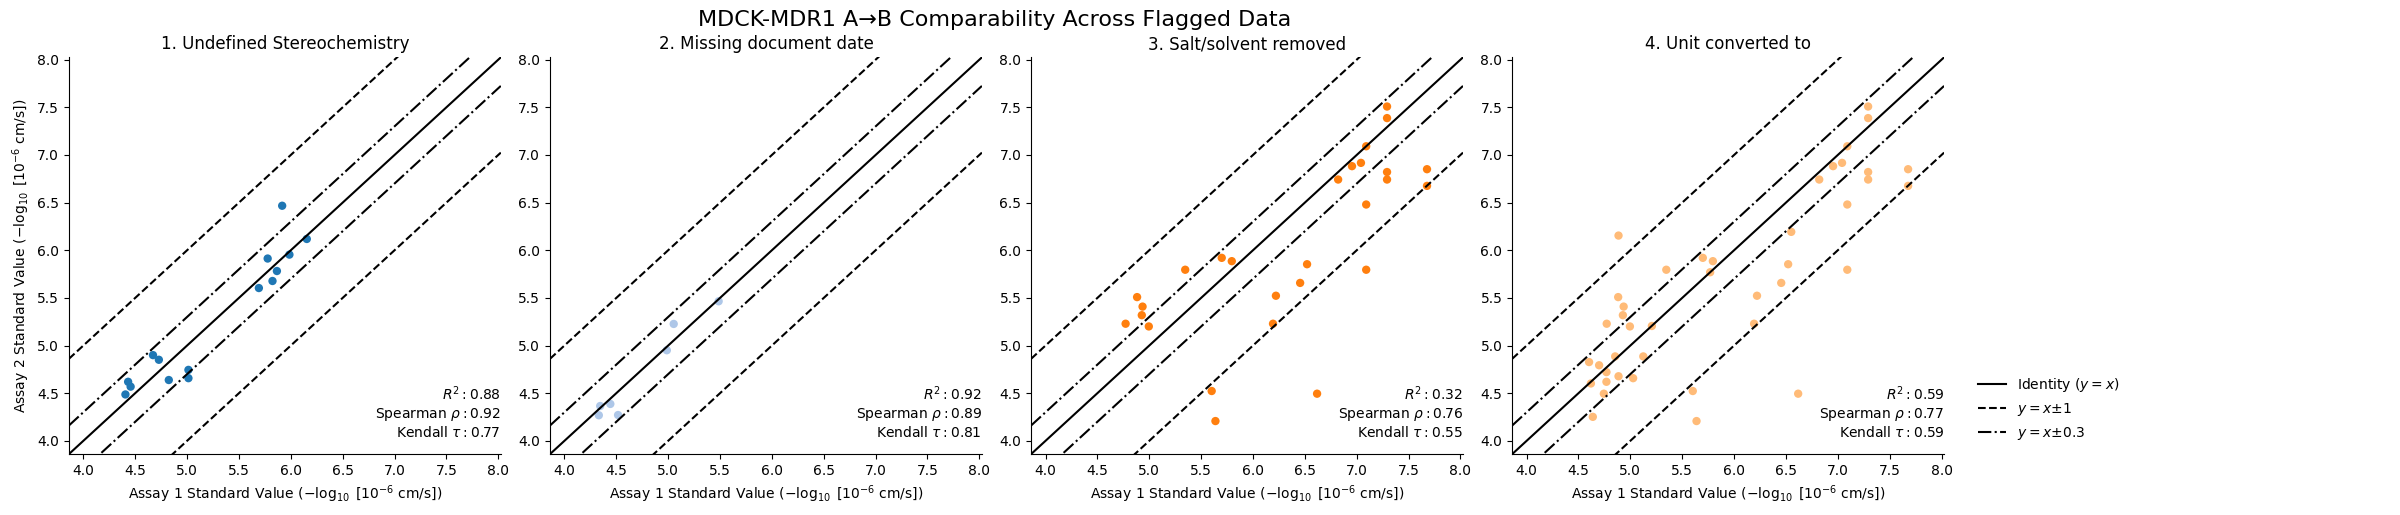

In [27]:
fig, axs = plot_multi_panel_comparability(
    mdck_exploded_a2b,
    all_comments,
    title="MDCK-MDR1 A\u2192B Comparability Across Flagged Data",
    figsize=(20, 5),
    ncols=4,
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=1,
)

fig.savefig("mdck_a2b_flagged_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

### MDCK-MDR1 Unprocessed A→B data

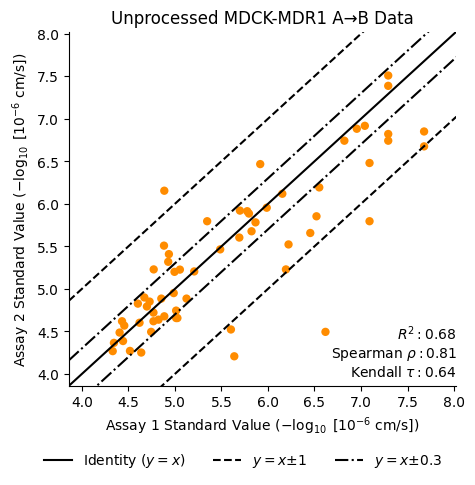

In [28]:
mdck_unprocessed_a2b = filter_dropping_flags(
    mdck_exploded_a2b.query("standard_value_x != standard_value_y"),
    [DroppingComment.DATA_VALIDITY_COMMENT, DroppingComment.POTENTIAL_DUPLICATE],
    column="dropping_comment",
)

fig, ax = plot_subset(
    mdck_unprocessed_a2b,
    title="Unprocessed MDCK-MDR1 A\u2192B Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=1,
    color="darkorange",
)
fig.savefig("mdck_a2b_unprocessed.png", dpi=300, bbox_inches="tight", transparent=False)

### MDCK-MDR1 Cleaned A→B data

2026-02-11 13:12:48 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:43 - Filtering 15 rows with flag: 'Undefined Stereochemistry'
2026-02-11 13:12:48 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:47 - Total rows filtered out: 15/62 (24.2%)


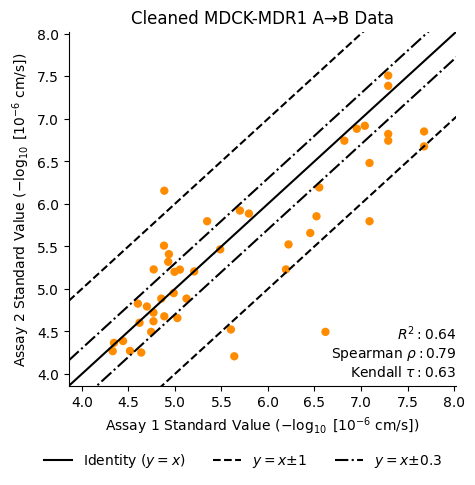

In [29]:
mdck_cleaned_a2b = filter_dropping_flags(
    mdck_exploded_a2b.query("standard_value_x != standard_value_y"),
    [
        DroppingComment.UNIT_ANNOTATION_ERROR,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY,
        DroppingComment.ASSAY_SIZE_TOO_SMALL,
    ],
    column="dropping_comment",
)

fig, ax = plot_subset(
    mdck_cleaned_a2b,
    title="Cleaned MDCK-MDR1 A\u2192B Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=1,
    color="darkorange",
)
fig.savefig("mdck_a2b_cleaned.png", dpi=300, bbox_inches="tight", transparent=False)

### MDCK-MDR1 Cross-assay comparability (B→A direction)

In [30]:
mdck_subset_b2a = mdck_b2a.query('assay_chembl_id.str.contains("|", regex=False)').assign(
    repeat=lambda x: range(len(x))
)
print(f"MDCK-MDR1 B→A compounds with multi-assay measurements: {len(mdck_subset_b2a)}")

mdck_exploded_b2a = explode_assay_comparability(
    mdck_subset_b2a,
    sep_str="|",
    value_column="standard_value",
)
print(f"Pairwise comparisons: {len(mdck_exploded_b2a)}")

MDCK-MDR1 B→A compounds with multi-assay measurements: 9
Pairwise comparisons: 5


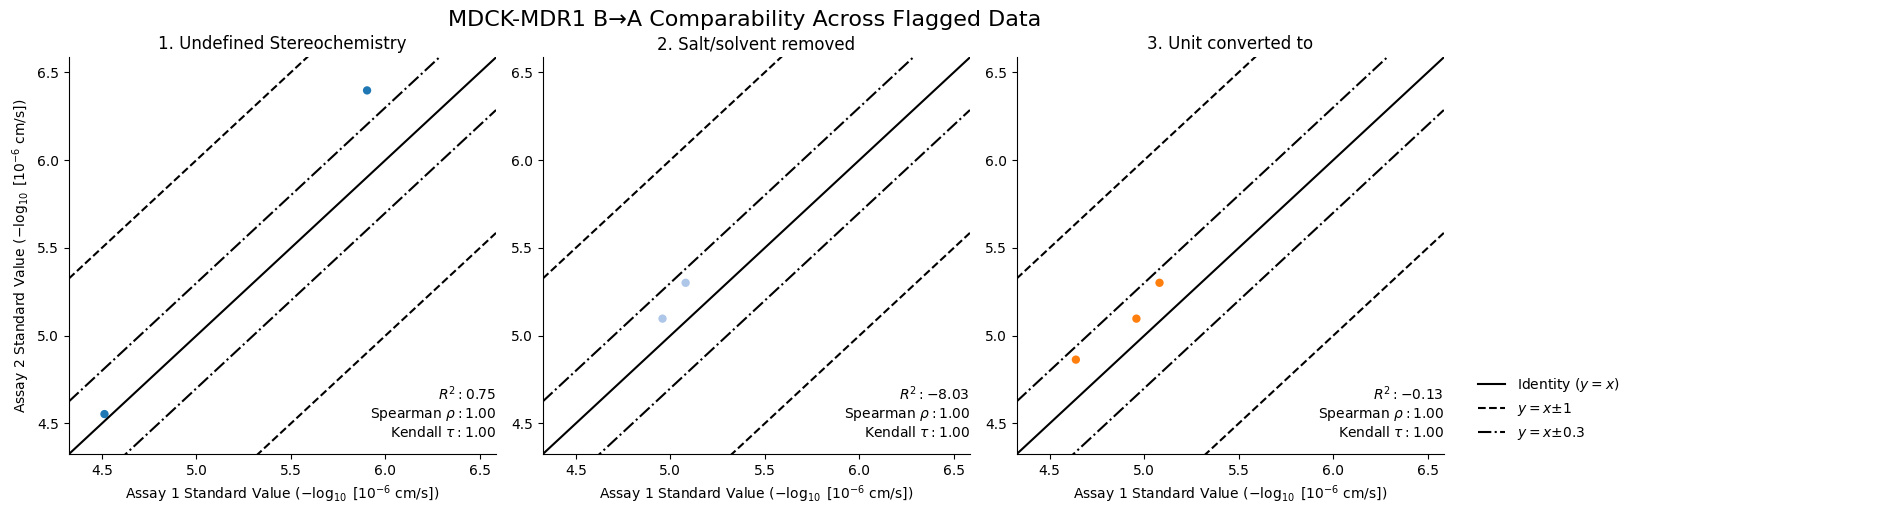

In [31]:
fig, axs = plot_multi_panel_comparability(
    mdck_exploded_b2a,
    all_comments,
    title="MDCK-MDR1 B\u2192A Comparability Across Flagged Data",
    figsize=(15, 5),
    ncols=3,
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=1,
)

fig.savefig("mdck_b2a_flagged_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

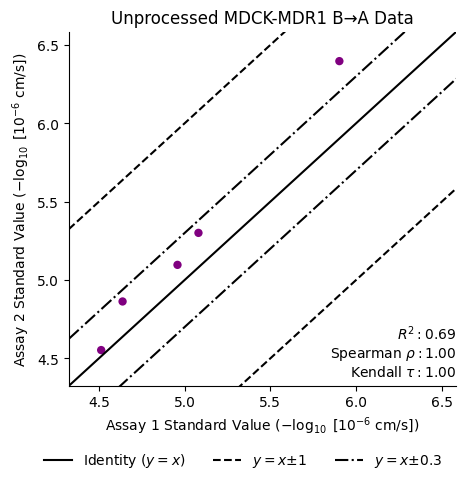

In [32]:
mdck_unprocessed_b2a = filter_dropping_flags(
    mdck_exploded_b2a.query("standard_value_x != standard_value_y"),
    [DroppingComment.DATA_VALIDITY_COMMENT, DroppingComment.POTENTIAL_DUPLICATE],
    column="dropping_comment",
)

fig, ax = plot_subset(
    mdck_unprocessed_b2a,
    title="Unprocessed MDCK-MDR1 B\u2192A Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=1,
    color="purple",
)

fig.savefig("mdck_b2a_unprocessed.png", dpi=300, bbox_inches="tight", transparent=False)

2026-02-11 13:13:16 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:43 - Filtering 2 rows with flag: 'Undefined Stereochemistry'
2026-02-11 13:13:16 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:47 - Total rows filtered out: 2/5 (40.0%)


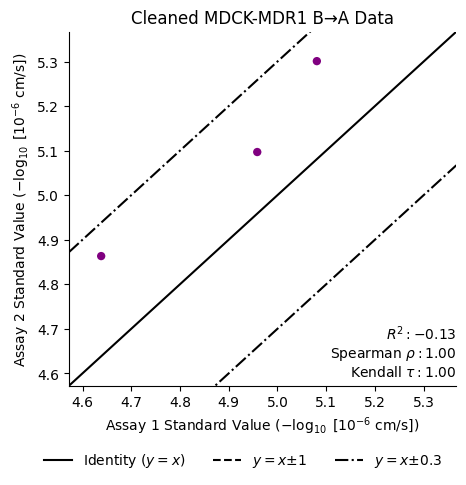

In [33]:
mdck_cleaned_b2a = filter_dropping_flags(
    mdck_exploded_b2a.query("standard_value_x != standard_value_y"),
    [
        DroppingComment.UNIT_ANNOTATION_ERROR,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY,
        DroppingComment.ASSAY_SIZE_TOO_SMALL,
    ],
    column="dropping_comment",
)

fig, ax = plot_subset(
    mdck_cleaned_b2a,
    title="Cleaned MDCK-MDR1 B\u2192A Data",
    figsize=(5, 4.6),
    value_column="standard_value",
    log_transform=True,
    log_scale_factor=1e-6,
    units="10^-6 cm/s",
    alpha=1,
    color="purple",
)

fig.savefig("mdck_b2a_cleaned.png", dpi=300, bbox_inches="tight", transparent=False)

### Prepare MDCK-MDR1 data for modeling

In [34]:
mdck_cleaned_a2b_prepared = clean_data(
    mdck_a2b,
    deduplicate=True,
    drop_flags=[
        DroppingComment.UNIT_ANNOTATION_ERROR.value,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY.value,
        DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
    ],
    value_col="standard_value",
)

mdck_cleaned_b2a_prepared = clean_data(
    mdck_b2a,
    deduplicate=True,
    drop_flags=[
        DroppingComment.UNIT_ANNOTATION_ERROR.value,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY.value,
        DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
    ],
    value_col="standard_value",
)

print(
    f"MDCK-MDR1 A\u2192B: {mdck_a2b.shape[0]} before cleaning & {len(mdck_cleaned_a2b_prepared)} after cleaning"
)
print(
    f"MDCK-MDR1 B\u2192A: {mdck_b2a.shape[0]} before cleaning & {len(mdck_cleaned_b2a_prepared)} after cleaning"
)

2026-02-11 13:13:18 | INFO     | Capricho.cli.prepare:clean_data:88 - Deduplicating identical values within aggregated rows...
2026-02-11 13:13:18 | INFO     | Capricho.cli.prepare:clean_data:96 - Deduplication removed 6 duplicate values
2026-02-11 13:13:18 | INFO     | Capricho.cli.prepare:clean_data:98 - Recalculating statistics after deduplication...
2026-02-11 13:13:18 | INFO     | Capricho.analysis:filter_aggregated_dropping_flags:293 - Rows with flag 'Undefined Stereochemistry': 691
2026-02-11 13:13:18 | INFO     | Capricho.analysis:filter_aggregated_dropping_flags:335 - Rows fully removed (all measurements flagged): 691
2026-02-11 13:13:18 | INFO     | Capricho.analysis:filter_aggregated_dropping_flags:339 - Total rows affected: 691/1397 (49.5%)
2026-02-11 13:13:18 | INFO     | Capricho.cli.prepare:clean_data:88 - Deduplicating identical values within aggregated rows...
2026-02-11 13:13:18 | INFO     | Capricho.cli.prepare:clean_data:96 - Deduplication removed 2 duplicate values

MDCK-MDR1 A→B: 1397 before cleaning & 706 after cleaning
MDCK-MDR1 B→A: 402 before cleaning & 221 after cleaning
